In [ ]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sc_toolbox as sct

[rank: 0] Global seed set to 0


In [ ]:
mpl.rcParams["figure.figsize"] = (5, 5)

In [ ]:
plt.rcParams['pdf.fonttype'] = 42

In [ ]:
adata = sc.read('../data/cellcharter_dmg_FINAL.h5ad')
adata

AnnData object with n_obs × n_vars = 26552 × 990
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA_MembraneStain_B2M', 'Max.rRNA_MembraneStain_B2M', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'sample', 'sample2', 'orig.ident', 'nCount_Nanostring', 'nFeature_Nanostring', 'Mean.rRNA_CD298_B2M', 'Max.rRNA_CD298_B2M', 'Slide_name', 'Run_name', 'ISH.concentration', 'Beta', 'tissue', 'Run_Slide_name', 'slide_ID_numeric', 'Run_Tissue_name', 'log10totalcounts', 'IFcolor', 'nb_clus', 'leiden_clus', 'id', 'FOV', 'PMCID', 'Replicate', 'ID_R', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'tangram_prediction', 'leiden', 'cellcharter_6', 'cellcharter_9', 'cellcharter_12'
    var: 'n_counts'
    uns: 'PMCID_colors', '_cellcharter', '_scvi_manager_uuid', '_scvi_uuid', 'cluster_cellcharter_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'spatial

In [ ]:
adata.layers['scaled'] = adata.X.copy()

# Scale the data in the 'scaled' layer using sc.pp.scale
sc.pp.scale(adata, layer='scaled')

In [ ]:
sc.tl.rank_genes_groups(adata, "tangram_prediction", layer="counts", method="wilcoxon")
de_df = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
de_df.head(20)

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,TD_like,GW_like,Oligodendrocyte,Mono_neutrophil,TAM_C1Q,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural
0,FABP7,EGFR,STMN2,MMP16,GPR17,AQP4,CLU,CHI3L1,HSPB1,SELENOP,LYZ,CD74,GPNMB,CD163,CD74,CX3CR1,IL7R,JCHAIN,IGFBP7,COL1A1
1,CLU,HES6,RBFOX3,OLIG1,SOX10,AQP1,AQP4,ITGA3,VIM,PTGDS,CD74,C1QC,SPP1,MRC1,CCL3,P2RY12,CD2,MS4A1,FLT1,COL3A1
2,VIM,DLL1,MET,PDGFRA,BCAS1,SPARCL1,SPARCL1,VEGFA,TGFB2,AATK,CLEC12A,SPP1,RGS1,CD74,OLR1,CD74,ITK,IRF4,ITM2A,COL1A2
3,MT1X,DLL3,BMP5,SOX10,BCAN,CLU,NTRK2,MEG3,JUN,APOD,HLA-DRA,GPX1,CD163,HLA-DRB1,CSF1R,ITGAX,IL32,MZB1,VWF,FN1
4,CD63,OLIG1,NRXN1,MYC,MMP16,NTRK2,GFAP,TIMP1,MEG3,GSN,HLA-DPA1,C1QB,TNFRSF14,HLA-DRA,SPP1,CSF1R,GZMA,HBA1,EPAS1,DCN
5,SOX2,METTL7B,NRG1,RPL34,FYN,CD38,AQP1,VIM,S100A6,FGFR2,CD163,HLA-DRA,ITGAX,C1QC,ITGAX,CSF2RA,STAT4,BMP6,ESAM,IGFBP7
6,CALM2,RARRES2,CHGA,BCAN,MYC,BCAN,SOX9,LGALS3,COL6A2,NDRG1,RGS2,B2M,C1QC,HLA-DPA1,IL1B,LPAR5,RUNX3,P2RX5,ENG,COL4A2
7,HSPB1,HES5,KRT24,CD24,RPL34,FGFR3,MALAT1,CAV1,MZT2A,FGF1,HLA-DRB1,HLA-DPA1,SRGN,SRGN,HLA-DRA,MAF,CCL5,SELL,CD34,COL4A1
8,SOX9,MEG3,MYH11,SOX4,SOX4,GFAP,DDR1,HILPDA,HGF,COL4A5,SRGN,SRGN,FCGR3A,HLA-DRB5,CSF2RA,SPP1,TXK,ESR1,FN1,PDGFRB
9,MT2A,CCND1,WNT7A,FGF12,RPL21,AGT,CRYAB,DUSP4,S100A10,COL18A1,CLEC7A,FCGR3A,CD68,C1QB,CX3CR1,C1QC,HBA1,ADGRG5,IFITM3,BGN


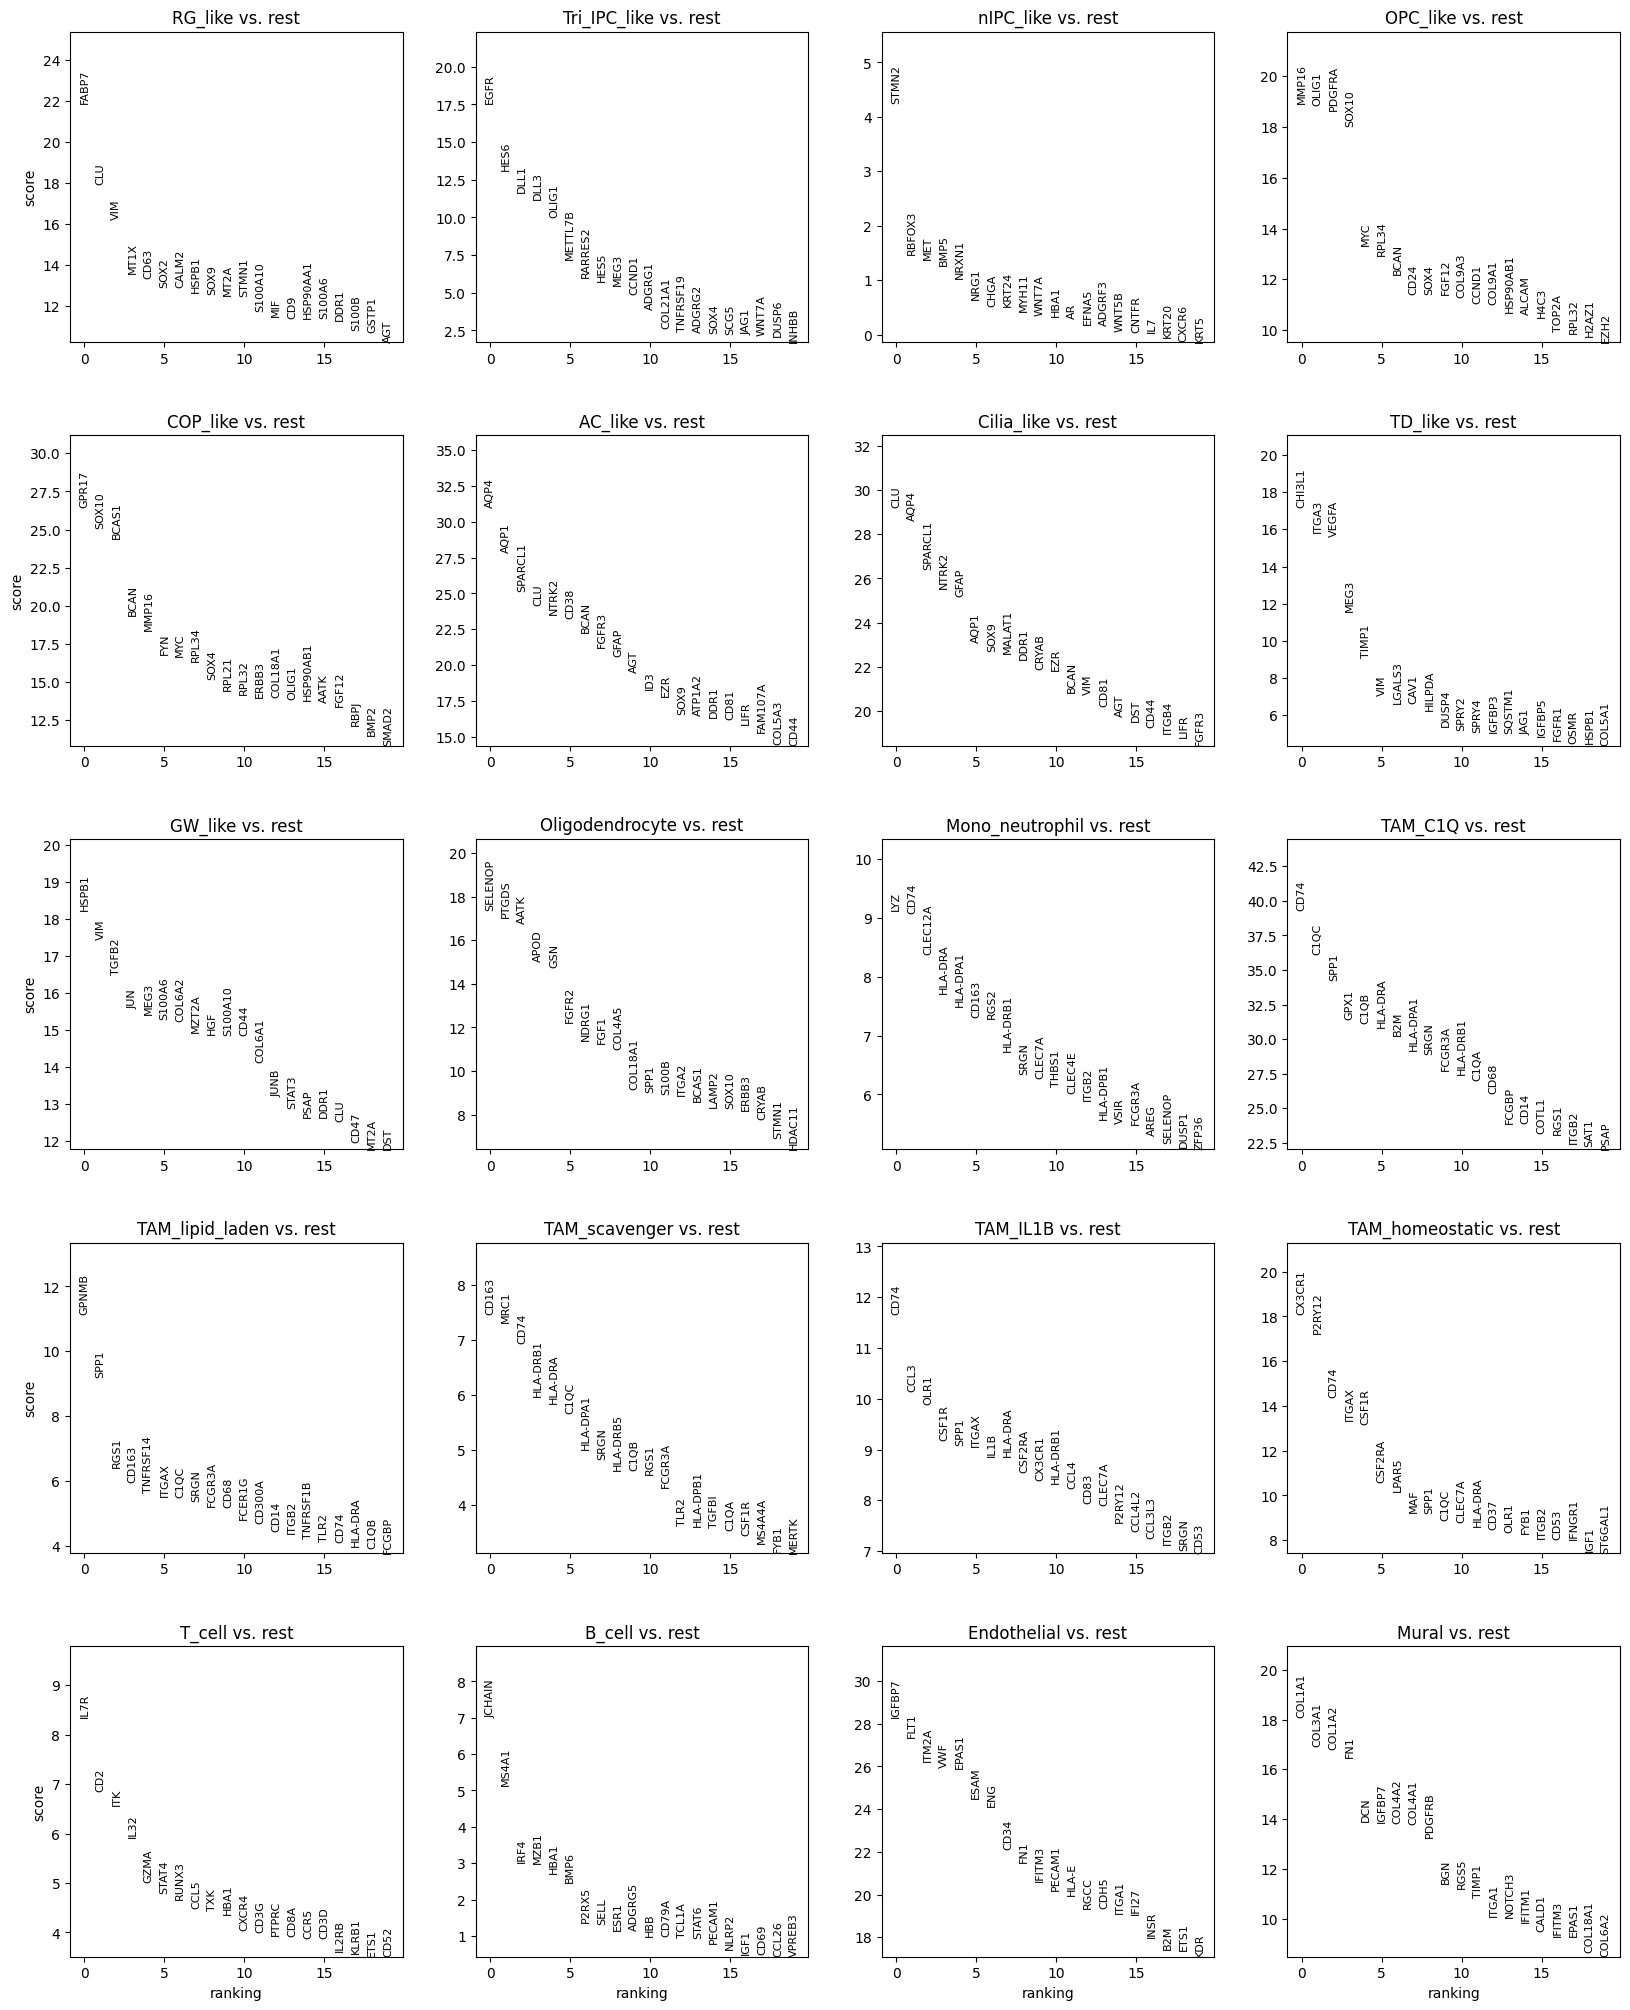

In [ ]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

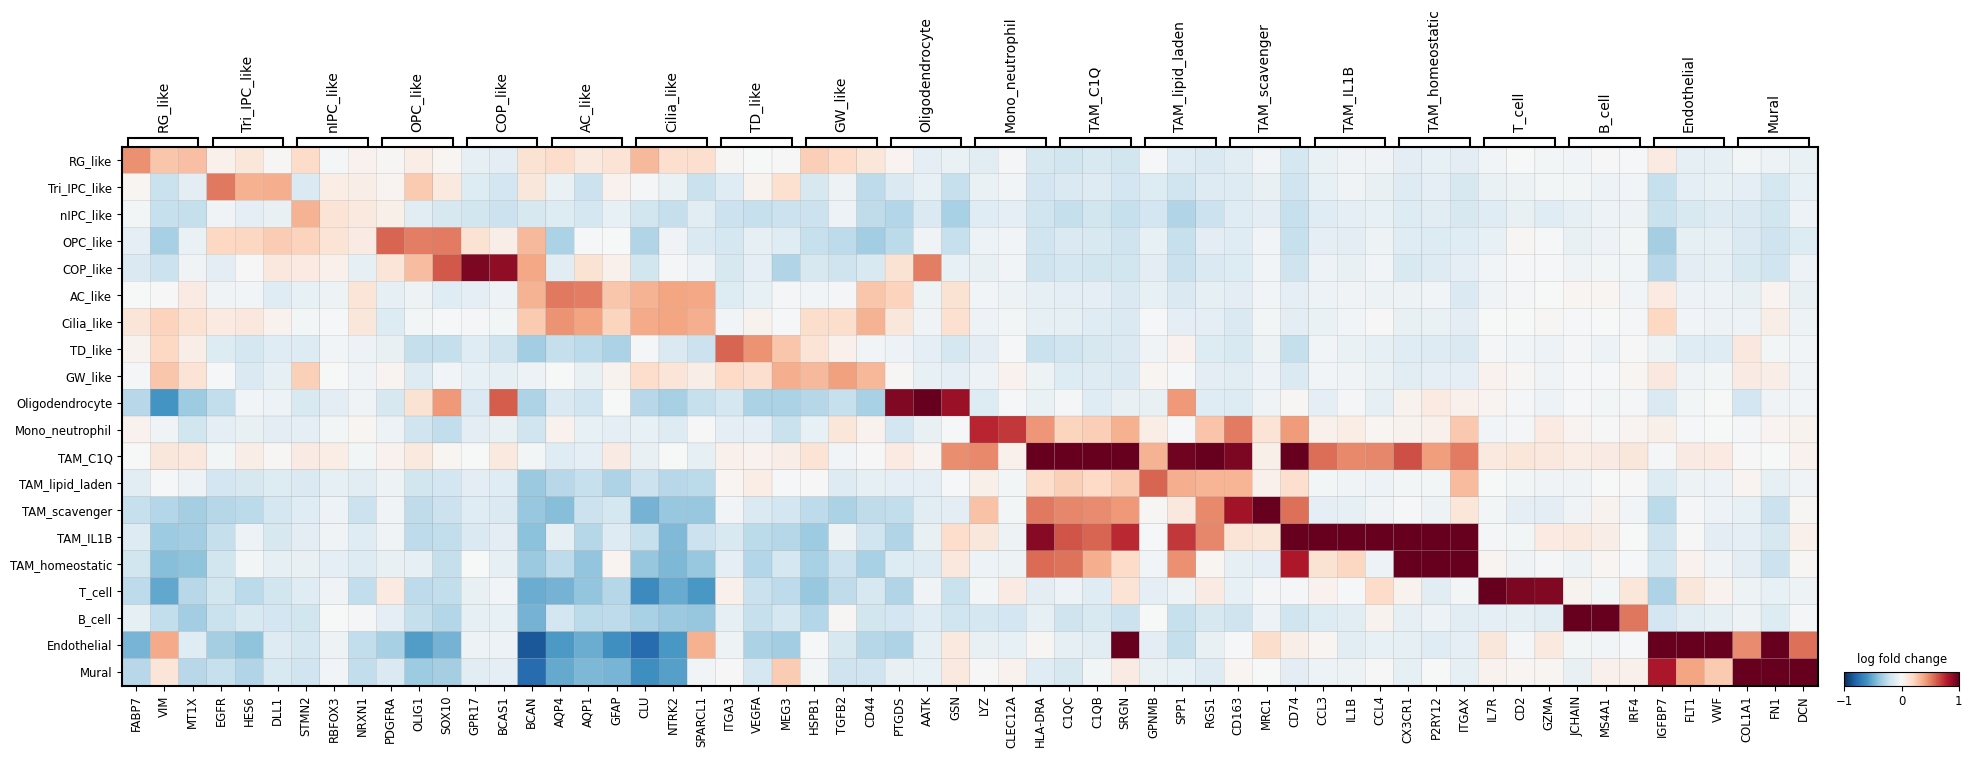

In [ ]:
# Define your new desired order for the categories
order = [
    'RG_like', 'Tri_IPC_like', 'nIPC_like', 'OPC_like',
    'COP_like', 'AC_like', 'Cilia_like', 'TD_like', 'GW_like',
    'Oligodendrocyte', 'Mono_neutrophil', 'TAM_C1Q',
    'TAM_lipid_laden', 'TAM_scavenger', 'TAM_IL1B',
    'TAM_homeostatic', 'T_cell', 'B_cell', 'Endothelial', 'Mural'
]
# Corresponding values
values = [
    ["FABP7", "VIM", "MT1X"],
    ["EGFR", "HES6", "DLL1"],
    ["STMN2", "RBFOX3", "NRXN1"],
    ["PDGFRA", "OLIG1", "SOX10"],
    ["GPR17", "BCAS1", "BCAN"],
    ["AQP4", "AQP1", "GFAP"],
    ["CLU", "NTRK2", "SPARCL1"],
    ["ITGA3", "VEGFA", "MEG3"],
    ["HSPB1", "TGFB2", "CD44"],
    ["PTGDS", "AATK", "GSN"],
    ["LYZ", "CLEC12A", "HLA-DRA"],
    ["C1QC", "C1QB", "SRGN"],
    ["GPNMB", "SPP1", "RGS1"],
    ["CD163", "MRC1", "CD74"],
    ["CCL3", "IL1B", "CCL4"],
    ["CX3CR1", "P2RY12", "ITGAX"],
    ["IL7R", "CD2", "GZMA"],
    ["JCHAIN", "MS4A1", "IRF4"],
    ["IGFBP7", "FLT1", "VWF"],
    ["COL1A1", "FN1", "DCN"]
]

# Create the dictionary
marker_genes = dict(zip(order, values))

dp = sc.pl.matrixplot(
    adata,
    marker_genes,
    groupby='tangram_prediction',
    cmap='RdBu_r',  # Use the reversed colormap
    vmin=-1,
    vmax=1,
    colorbar_title='log fold change',
    layer="scaled",
    save='figures/marker_genes_tangram_cosmx.pdf'
)


In [ ]:
sc.set_figure_params(scanpy=True, dpi=500, dpi_save=500, frameon=False, vector_friendly=True, fontsize=7, figsize=None, color_map=None, format='pdf', facecolor=None, transparent=False, ipython_format='png2x')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

probs = adata.obsm['tangram_ct_pred'].copy()
probs.columns = probs.columns.astype(str)

probs['tangram_prediction'] = adata.obs['tangram_prediction'].astype(str)

# Calculate mean probabilities per tangram_prediction
mean_probs = probs.groupby('tangram_prediction').mean()

In [ ]:
new_order = ['RG_like', 'Tri_IPC_like', 'nIPC_like', 'OPC_like', 'COP_like', 'AC_like', 'Cilia_like', 
             'TD_like', 'GW_like', 'Oligodendrocyte', 'Mono_neutrophil', 'TAM_C1Q', 'TAM_lipid_laden', 
             'TAM_scavenger', 'TAM_IL1B', 'TAM_homeostatic', 'T_cell', 'B_cell', 'Endothelial', 'Mural']

colors = [
    '#74150f', '#b26671', '#fdc955', '#c13910', '#f4e5e1', '#caa4ab',
    '#8f7308', '#ba7db3', '#5c2454', '#bae7c2', '#00a69c', '#165884',
    '#7b7dba', '#95bbcd', '#343682', '#26a9e0', '#ffbb78', '#474747',
    '#217236', '#a24600'
]

color_mapping = dict(zip(new_order, colors))

row_colors = pd.Series(new_order, index=new_order).map(color_mapping)
col_colors = row_colors

mean_probs = mean_probs.loc[new_order, new_order]

sns.clustermap(
    mean_probs, 
    cmap='BuPu', 
    annot=False, 
    vmax=0.4, 
    vmin=0.05, 
    linewidths=None, 
    linecolor=None, 
    row_colors=row_colors, 
    col_colors=col_colors,
    col_cluster=False,  
    row_cluster=False 
)

plt.title('Tangram Prediction Scores')
plt.xlabel('Predicted Labels')
plt.savefig('figures/tangram_prediction.pdf')
plt.show()

### R kernel

In [1]:
library(Seurat)
# options(Seurat.object.assay.version = "v5")
library(ggplot2)
library(dittoSeq)
library(dplyr)
library(future)
library(tidyr)
library(tibble)
library(purrr)
library(magrittr)
source("../scripts/subset_obj_seurat.R") # load the intermediate solution function
# https://github.com/satijalab/seurat/issues/6409

plan("multicore", workers = 12)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract




In [2]:
dmg_st <- readRDS('/projects/0/einf2548/cruiz/dmg/ST/SMI-0262_Broek.Vuurden_PrinsesMaxima-selected/6 Analysis/Data objects/seurat_object.Rds')
dmg_st

An object of class Seurat 
1008 features across 63439 samples within 1 assay 
Active assay: Nanostring (1008 features, 0 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap
 2 spatial fields of view present: R5779.TMA2.S6 R5779.TMA3.S4

In [4]:
fov <- readxl::read_excel('/projects/0/einf2548/cruiz/dmg/data/FOV-sample.xlsx') %>%
            filter(Tumor %in% c('Diffuse non-midline glioma (H3K27M)',
                               'DMG')) 
fov$FOV <- stringr::str_replace_all(fov$FOV, "R", "Run")
fov

FOV,PMCID,Replicate,Tumor,Slide
<chr>,<chr>,<chr>,<chr>,<dbl>
Run5779_S2_FOV12,PMCID448AAQ,R1,Diffuse non-midline glioma (H3K27M),2
Run5779_S2_FOV22,PMCID448AAQ,R2,Diffuse non-midline glioma (H3K27M),2
Run5779_S2_FOV23,PMCID448AAQ,R3,Diffuse non-midline glioma (H3K27M),2
Run5779_S2_FOV6,PMCID448AAQ,R4,Diffuse non-midline glioma (H3K27M),2
Run5779_S3_FOV 19,PMCID789AAQ,R1,DMG,3
Run5779_S3_FOV20,PMCID212AAQ,R1,DMG,3
Run5779_S3_FOV21,PMCID977AAO,R1,DMG,3
Run5779_S3_FOV16,PMCID957AAQ,R1,DMG,3
Run5779_S3_FOV13,PMCID957AAQ,R2,DMG,3


In [5]:
dmg_st$FOV <- paste0(dmg_st$Run_Slide_name, '_FOV', dmg_st$fov)
table(dmg_st$FOV)


 Run5779_S2_FOV1 Run5779_S2_FOV10 Run5779_S2_FOV12 Run5779_S2_FOV13 
             904              724              770              598 
Run5779_S2_FOV14 Run5779_S2_FOV15 Run5779_S2_FOV16 Run5779_S2_FOV17 
            1397              477             1048             2116 
Run5779_S2_FOV18 Run5779_S2_FOV19  Run5779_S2_FOV2 Run5779_S2_FOV20 
            1994              846             3218             1499 
Run5779_S2_FOV21 Run5779_S2_FOV22 Run5779_S2_FOV23 Run5779_S2_FOV24 
            1512             1282              857             1209 
Run5779_S2_FOV25 Run5779_S2_FOV26  Run5779_S2_FOV3  Run5779_S2_FOV4 
             855              768             1578             3162 
 Run5779_S2_FOV5  Run5779_S2_FOV6  Run5779_S2_FOV7  Run5779_S2_FOV8 
            3263             1212              767              924 
 Run5779_S2_FOV9  Run5779_S3_FOV1 Run5779_S3_FOV10 Run5779_S3_FOV11 
            1469             1431              107             1691 
Run5779_S3_FOV12 Run5779_S3_FOV13

In [6]:
# https://github.com/satijalab/seurat/issues/6409
nano.obj <- subset_opt(dmg_st, FOV %in% fov$FOV)
nano.obj

Updating object slots..

Cloing object..

Extracting cells matched to `subset` and/or `idents`

Matching cells in FOVs..

Cell subsets are found in all FOVs!
Subsetting object..

Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Key ‘Nanostring_’ taken, using ‘r5779tma2s6_’ instead”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“N

An object of class Seurat 
1008 features across 26552 samples within 1 assay 
Active assay: Nanostring (1008 features, 0 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap
 2 spatial fields of view present: R5779.TMA2.S6 R5779.TMA3.S4

In [7]:
meta <- merge(nano.obj@meta.data %>% mutate(cell = rownames(nano.obj@meta.data)), 
      fov %>% mutate(ID_R = paste0(PMCID, '_', Replicate)), 
      by = 'FOV') %>% select(cell, FOV,PMCID,Replicate,ID_R) %>%
     column_to_rownames('cell')
meta

,FOV,PMCID,Replicate,ID_R
,<chr>,<chr>,<chr>,<chr>
R5779.TMA2-S6_2_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1
R5779.TMA2-S6_3_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1
R5779.TMA2-S6_4_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1
R5779.TMA2-S6_5_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1
R5779.TMA2-S6_6_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1
R5779.TMA2-S6_7_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1
R5779.TMA2-S6_8_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1
R5779.TMA2-S6_9_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1
R5779.TMA2-S6_10_12,Run5779_S2_FOV12,PMCID448AAQ,R1,PMCID448AAQ_R1


In [8]:
nano.obj <- AddMetaData(nano.obj, meta)

In [9]:
cellcharter <- read.csv('../data/cellcharter_dmg.csv')%>%column_to_rownames('X')
cellcharter

,fov,Area,AspectRatio,CenterX_global_px,CenterY_global_px,Width,Height,Mean.Histone,Max.Histone,Mean.G,⋯,ID_R,n_counts,X_scvi_batch,X_scvi_labels,cluster_cellcharter,tangram_prediction,leiden,cellcharter_6,cellcharter_9,cellcharter_12
,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
R5779.TMA2-S6_1_6,6,13541,2.06,-91818.59,24598.08,196,95,1574,14424,24,⋯,PMCID448AAQ_R4,248,6,0,6,TD_like,8,1,1,1
R5779.TMA2-S6_2_6,6,9866,1.49,-90783.59,24597.08,145,97,2271,22200,24,⋯,PMCID448AAQ_R4,406,6,0,6,OPC_like,4,1,1,1
R5779.TMA2-S6_3_6,6,11085,1.44,-91065.59,24595.08,147,102,705,4696,10,⋯,PMCID448AAQ_R4,662,6,0,6,Cilia_like,2,1,1,1
R5779.TMA2-S6_4_6,6,6931,0.98,-94113.59,24577.08,107,109,2350,8616,4,⋯,PMCID448AAQ_R4,241,6,0,6,RG_like,8,1,1,1
R5779.TMA2-S6_5_6,6,10243,1.22,-91193.59,24552.08,151,124,3616,14776,20,⋯,PMCID448AAQ_R4,581,6,0,6,Cilia_like,2,1,1,1
R5779.TMA2-S6_6_6,6,9699,0.54,-93009.59,24539.08,98,181,2915,11224,20,⋯,PMCID448AAQ_R4,495,6,0,6,GW_like,2,1,1,1
R5779.TMA2-S6_7_6,6,29410,0.92,-92008.59,24512.08,229,250,1520,14120,21,⋯,PMCID448AAQ_R4,1358,6,0,6,nIPC_like,2,1,1,1
R5779.TMA2-S6_8_6,6,9096,1.03,-94356.59,24542.08,122,118,2167,11144,8,⋯,PMCID448AAQ_R4,517,6,0,6,RG_like,2,1,1,1
R5779.TMA2-S6_9_6,6,16921,1.05,-92911.59,24512.08,178,170,2477,17624,20,⋯,PMCID448AAQ_R4,772,6,0,6,Cilia_like,2,1,1,1


In [11]:
nano.obj <- AddMetaData(nano.obj, cellcharter %>% select(c('tangram_prediction',	'cellcharter_6',	'cellcharter_9',	'cellcharter_12')))
nano.obj

An object of class Seurat 
1008 features across 26552 samples within 1 assay 
Active assay: Nanostring (1008 features, 0 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap
 2 spatial fields of view present: R5779.TMA2.S6 R5779.TMA3.S4

In [12]:
nano.obj$tangram_prediction <- factor(nano.obj$tangram_prediction,
                                     levels=c('RG_like', 'Tri_IPC_like','nIPC_like','OPC_like',
             'COP_like','AC_like','Cilia_like','TD_like','GW_like',
                                              'Oligodendrocyte',
             'Mono_neutrophil',
             'TAM_C1Q','TAM_lipid_laden','TAM_scavenger','TAM_IL1B','TAM_homeostatic',
             'T_cell','B_cell',
                                             'Endothelial', 'Mural'))

In [13]:
nano.obj$PMCID_FOV <- paste0(nano.obj$PMCID,'_FOV', nano.obj$fov)

In [14]:
table(nano.obj$PMCID_FOV)


 PMCID099AAQ_FOV2 PMCID099AAQ_FOV23  PMCID190AAO_FOV5  PMCID190AAO_FOV9 
             1151              1204               816              1737 
PMCID212AAK_FOV11 PMCID212AAK_FOV14 PMCID212AAK_FOV17 PMCID212AAQ_FOV20 
             1691              1845              1866               789 
PMCID291AAN_FOV12 PMCID291AAN_FOV15 PMCID291AAN_FOV18  PMCID367AAQ_FOV8 
             1749              2267              2037               465 
PMCID448AAQ_FOV12 PMCID448AAQ_FOV22 PMCID448AAQ_FOV23  PMCID448AAQ_FOV6 
              770              1282               857              1212 
PMCID577AAL_FOV24 PMCID577AAL_FOV25  PMCID577AAL_FOV3 PMCID957AAQ_FOV10 
              672               728              1818               107 
PMCID957AAQ_FOV13 PMCID957AAQ_FOV16 PMCID977AAO_FOV21 
              133                87              1269 

In [15]:
colors <- c('#74150f', '#b26671', '#fdc955', '#c13910',
          '#f4e5e1', '#caa4ab', '#8f7308', '#ba7db3', '#5c2454',
            '#bae7c2',
          '#00a69c', 
           '#165884', '#7b7dba', '#95bbcd', '#343682', '#26a9e0',
           '#ffbb78','#474747', 
           '#217236','#a24600'
          )

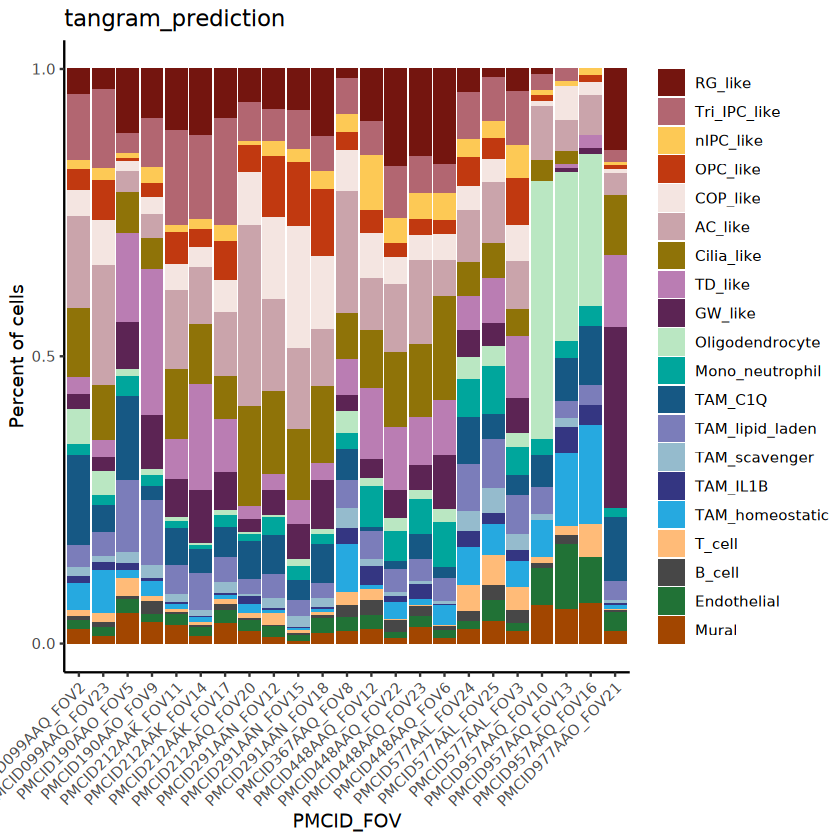

In [17]:
dittoBarPlot(nano.obj, var = 'tangram_prediction', color.panel = colors,
             group.by = 'PMCID_FOV', retain.factor.levels = TRUE)

In [18]:
ggsave('figures/cell_proportions_tangram_cosmx.pdf')

Saving 6.67 x 6.67 in image


In [25]:
colors <- c('#74150f', '#b26671', '#fdc955', '#c13910',
          '#f4e5e1', '#caa4ab', '#8f7308', '#ba7db3', '#5c2454',
            '#bae7c2',
          '#00a69c', 
           '#165884', '#7b7dba', '#95bbcd', '#343682', '#26a9e0',
           '#ffbb78','#474747', 
           '#217236','#a24600'
          )

In [29]:
# Create an empty list to store the images
all_images <- list()

# Get unique FOV values
unique_fov <- unique(nano.obj$FOV)

# Loop through each FOV
for (fov_value in unique_fov) {
  # Subset the data for the current FOV
  fov_dmg <- subset_opt(nano.obj, subset = FOV == fov_value)
  
  # Generate ImageDimPlot using polychrome palette
  image_plot <- ImageDimPlot(fov_dmg, axes = FALSE, 
                             cols = colors, group.by = 'tangram_prediction',
                            coord.fixed = FALSE)
    
niche_plot <- ImageDimPlot(fov_dmg, axes = FALSE, 
                            group.by = 'cellcharter_9',
                           cols=dittoColors(),
                            coord.fixed = FALSE)  
  # Store the images in the list
  all_images[[fov_value]] <- list(image_plot + ggtitle(fov_value),
                                  niche_plot + ggtitle(fov_value))
                                  
}

Updating object slots..

Cloing object..

Extracting cells matched to `subset` and/or `idents`

Matching cells in FOVs..

Cell subsets are found only in FOV: 
R5779.TMA2.S6

Subsetting Centroids..

Removing FOVs where cells are NOT found: 
R5779.TMA3.S4

Subsetting cells..

Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Updating object..

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘umap’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or p

In [31]:
# Specify the output PDF file
pdf("figures/cosmx_fov_tangram_predictions.pdf", width = 8, height = 6)  # Adjust width and height as needed

# Loop through the list of images and print each one
for (fov_value in names(all_images)) {
  print(all_images[[fov_value]])
}

# Close the PDF device
dev.off()

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]



png 
  2

In [32]:
# Create an empty list to store the images
all_images <- list()

# Get unique FOV values
unique_fov <- unique(nano.obj$FOV)

# Loop through each FOV
for (fov_value in unique_fov) {
  # Subset the data for the current FOV
  fov_dmg <- subset_opt(nano.obj, subset = FOV == fov_value)
  
  # Generate ImageDimPlot using polychrome palette
  image_plot <- ImageDimPlot(fov_dmg, axes = FALSE, 
                             border.size = 0,
                             cols = colors, group.by = 'tangram_prediction',
                            coord.fixed = FALSE)
    
niche_plot <- ImageDimPlot(fov_dmg, axes = FALSE, 
                            group.by = 'cellcharter_9',
                           cols=dittoColors(),
                            coord.fixed = FALSE)  
  # Store the images in the list
  all_images[[fov_value]] <- list(image_plot + ggtitle(fov_value),
                                  niche_plot + ggtitle(fov_value))
                                  
}

Updating object slots..

Cloing object..

Extracting cells matched to `subset` and/or `idents`

Matching cells in FOVs..

Cell subsets are found only in FOV: 
R5779.TMA2.S6

Subsetting Centroids..

Removing FOVs where cells are NOT found: 
R5779.TMA3.S4

Subsetting cells..

Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Updating object..

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘umap’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or p

In [ ]:
# Specify the output PDF file
pdf("figures/cosmx_fov_tangram_predictions_no_border.pdf", width = 8, height = 6)  # Adjust width and height as needed

# Loop through the list of images and print each one
for (fov_value in names(all_images)) {
  print(all_images[[fov_value]])
}

# Close the PDF device
dev.off()

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]

[[1]]

[[2]]
